# 1.IMPORTING DATASET

In [14]:
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, roc_auc_score, classification_report,
    roc_curve, precision_recall_curve, confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 讀取 CSV 檔案
df = pd.read_csv("/content/Phishing_Email.csv")

# 顯示前幾筆資料
print(df.head())

   Unnamed: 0                                         Email Text  \
0           0  re : 6 . 1100 , disc : uniformitarianism , re ...   
1           1  the other side of * galicismos * * galicismo *...   
2           2  re : equistar deal tickets are you still avail...   
3           3  \nHello I am your hot lil horny toy.\n    I am...   
4           4  software at incredibly low prices ( 86 % lower...   

       Email Type  
0      Safe Email  
1      Safe Email  
2      Safe Email  
3  Phishing Email  
4  Phishing Email  


In [3]:
print(df['Email Type'].value_counts())

Email Type
Safe Email        11322
Phishing Email     7328
Name: count, dtype: int64


# 2.DATA PRE-PROCESSING

In [4]:
# 1. 處理遺失值
df.dropna(subset=['Email Text', 'Email Type'], inplace=True)
df = df.reset_index(drop=True)
df['label'] = df['Email Type'].apply(lambda x: 1 if 'Phishing' in x else 0)
y = df['label']

# 2. 文字清理函數
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    return text

df['clean_text'] = df['Email Text'].apply(clean_text)  # 對郵件內容執行清理

# 3. Handcrafted Features
def extract_features(text):
    words = re.findall(r'\b\w+\b', text.lower())
    num_words = len(words)
    num_unique_words = len(set(words))
    stopwords = ["the", "and", "in", "a", "of", "to", "is", "it", "for", "that"]
    num_stopwords = sum(1 for word in words if word in stopwords)
    num_links = len(re.findall(r'http[s]?://|www\.', text))
    num_email_addresses = len(re.findall(r'\S+@\S+', text))
    num_special_chars = len(re.findall(r'[!@#$%^&*?,.:;\'\"()\[\]\{\}\|\\/<>=-]', text))
    num_digits = len(re.findall(r'\d', text))
    urgent_keywords = ["urgent", "verify", "account", "password", "login", "security", "important", "alert"]
    num_urgent_keywords = sum(1 for word in words if word in urgent_keywords)
    avg_word_length = np.mean([len(w) for w in words]) if words else 0
    num_uppercase_words = sum(1 for w in words if w.isupper())

    return pd.Series({
        'num_words': num_words,
        'num_unique_words': num_unique_words,
        'num_stopwords': num_stopwords,
        'num_links': num_links,
        'num_email_addresses': num_email_addresses,
        'num_special_chars': num_special_chars,
        'num_digits': num_digits,
        'num_urgent_keywords': num_urgent_keywords,
        'avg_word_length': avg_word_length,
        'num_uppercase_words': num_uppercase_words
    })

features_df = df['Email Text'].apply(extract_features)

# 4. 切分訓練/驗證/測試集（70/15/15）
idx = np.arange(len(df))
idx_temp, idx_test = train_test_split(
    idx, test_size=0.15, stratify=y, random_state=42)
idx_train, idx_val = train_test_split(
    idx_temp, test_size=0.15/0.85, stratify=y.iloc[idx_temp], random_state=42)

# 5. TF-IDF 僅以訓練集擬合
tfidf = TfidfVectorizer(max_features=1000, stop_words='english')
tfidf.fit(df.loc[idx_train, 'clean_text'])

# 6. 整合所有特徵
def build_X(indices):
    tfidf_part = tfidf.transform(df.loc[indices, 'clean_text'])
    tfidf_df = pd.DataFrame(tfidf_part.toarray(), columns=tfidf.get_feature_names_out())
    return pd.concat([features_df.loc[indices].reset_index(drop=True), tfidf_df], axis=1)

X_train, X_val, X_test = build_X(idx_train), build_X(idx_val), build_X(idx_test)
y_train = y.iloc[idx_train].reset_index(drop=True)
y_val   = y.iloc[idx_val].reset_index(drop=True)
y_test  = y.iloc[idx_test].reset_index(drop=True)

print(f"Train: {len(X_train)} | Validation: {len(X_val)} | Test: {len(X_test)}")

Train: 13043 | Validation: 2795 | Test: 2796


In [5]:
# 檢查各資料集類別比例
for name, labels in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    print(f"\n{name} set label distribution:")
    print(labels.value_counts(normalize=True))


Train set label distribution:
label
0    0.607606
1    0.392394
Name: proportion, dtype: float64

Validation set label distribution:
label
0    0.607513
1    0.392487
Name: proportion, dtype: float64

Test set label distribution:
label
0    0.607654
1    0.392346
Name: proportion, dtype: float64


# 3.Training and Testing

In [6]:
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

# 1. 建立與訓練模型（僅用訓練集）
model = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight
)
model.fit(X_train, y_train)

# 2. 以驗證集找最佳 threshold
y_val_proba = model.predict_proba(X_val)[:, 1]

best_thresh = 0.5
best_mcc = -1
for t in np.arange(0.3, 0.7, 0.01):
    y_temp = (y_val_proba > t).astype(int)
    mcc = matthews_corrcoef(y_val, y_temp)
    if mcc > best_mcc:
        best_mcc = mcc
        best_thresh = t

print(f"Optimal Threshold (by MCC on validation set): {best_thresh:.2f}")

# 3. Predict on TEST set (evaluated only once) 以測試集進行最終預測
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba > best_thresh).astype(int)

Optimal Threshold (by MCC on validation set): 0.62


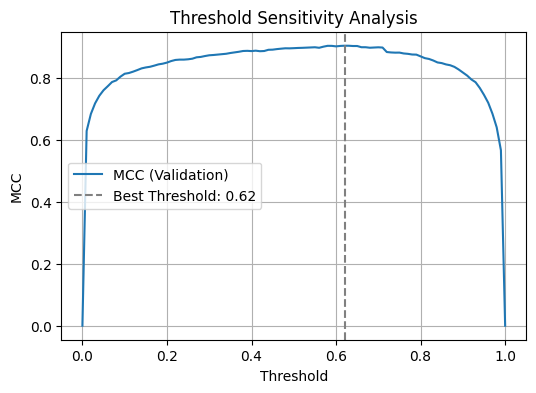

In [7]:
# Threshold Sensitivity Analysis on validation set 門檻靈敏度分析圖（驗證集）
mcc_list = []
thresholds = np.arange(0.0, 1.01, 0.01)
for t in thresholds:
    y_temp = (y_val_proba > t).astype(int)
    mcc_list.append(matthews_corrcoef(y_val, y_temp))

plt.figure(figsize=(6,4))
plt.plot(thresholds, mcc_list, label="MCC (Validation)")
plt.axvline(x=best_thresh, color='gray', linestyle='--', label=f'Best Threshold: {best_thresh:.2f}')
plt.xlabel("Threshold")
plt.ylabel("MCC")
plt.title("Threshold Sensitivity Analysis")
plt.legend()
plt.grid(True)
plt.show()

In [8]:
# 測試集評估指標
# Classification Report
print("\nClassification Report (Test set):\n")
print(classification_report(y_test, y_pred, target_names=['Safe', 'Phishing']))

print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred):.4f}")
print(f"MCC: {matthews_corrcoef(y_test, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")


Classification Report (Test set):

              precision    recall  f1-score   support

        Safe       0.96      0.95      0.96      1699
    Phishing       0.93      0.95      0.94      1097

    accuracy                           0.95      2796
   macro avg       0.95      0.95      0.95      2796
weighted avg       0.95      0.95      0.95      2796


Accuracy: 0.9514
Precision: 0.9309
Recall: 0.9462
F1-score: 0.9385
MCC: 0.8984
ROC-AUC: 0.9902


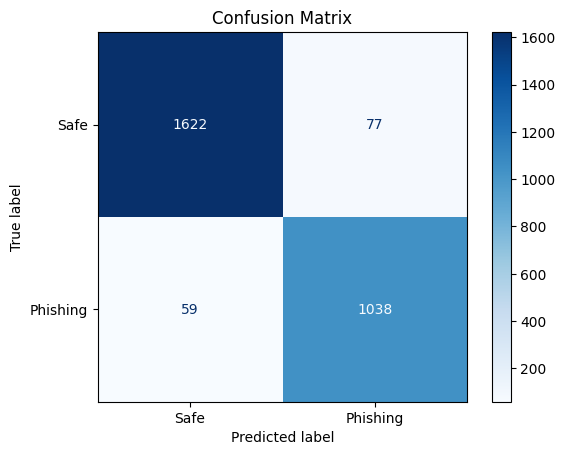

In [11]:
# confusion_matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Safe', 'Phishing'])
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Confusion Matrix')
plt.grid(False)
plt.show()

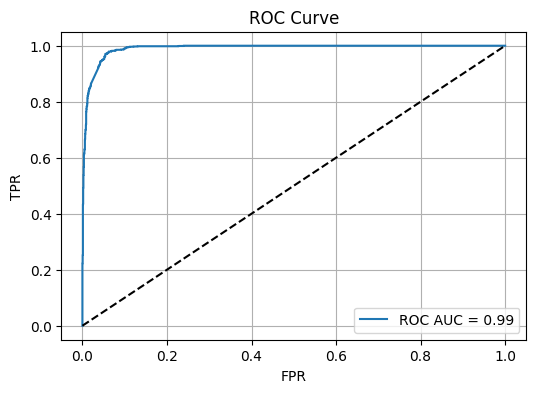

In [9]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc_score(y_test, y_pred_proba):.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('ROC Curve'); plt.legend()
plt.grid(True)
plt.show()

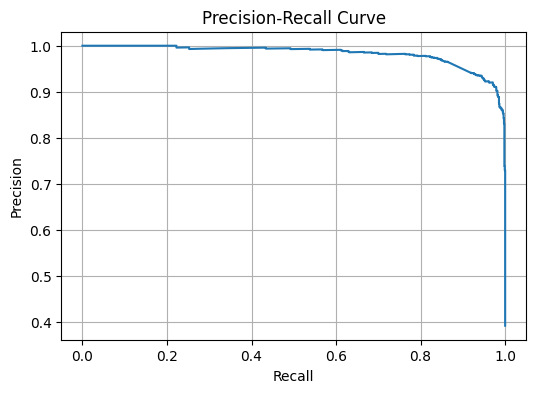

In [10]:
# PR Curve
precision_pr, recall_pr, _ = precision_recall_curve(y_test, y_pred_proba)
plt.figure(figsize=(6, 4))
plt.plot(recall_pr, precision_pr, label="PR Curve")
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.show()

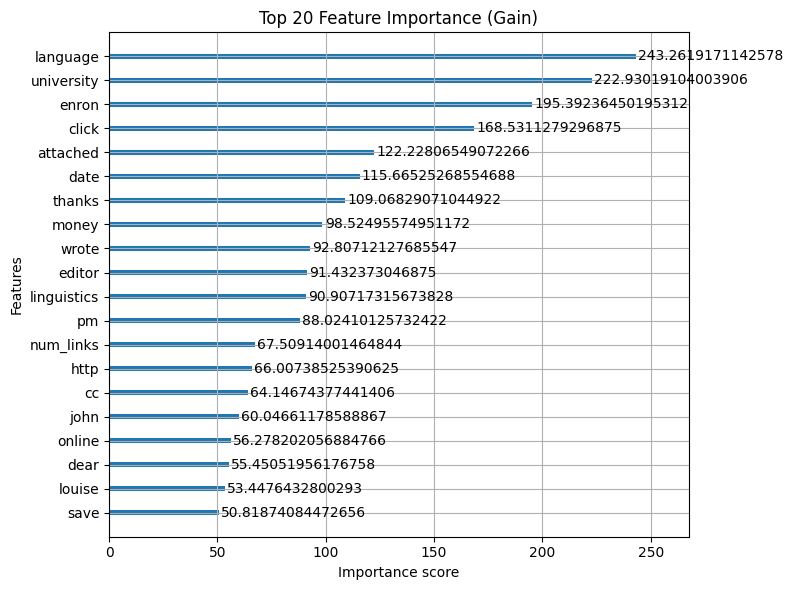

In [12]:
# 特徵重要性（Feature Importance）
from xgboost import plot_importance

fig, ax = plt.subplots(figsize=(8, 6))
plot_importance(model, importance_type='gain', max_num_features=20, ax=ax)
plt.title('Top 20 Feature Importance (Gain)')
plt.tight_layout()
plt.show()